1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Load and Preprocess IMDb Dataset

In [2]:
# Load dataset
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


c:\Users\PRITHEW\Desktop\Academics\Machine_Learning\my_env\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training samples: 25000
Testing samples: 25000


Pad Sequences

In [3]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post')

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


3. Build Simple RNN Model

In [4]:
simple_rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

simple_rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

simple_rnn_model.summary()

c:\Users\PRITHEW\Desktop\Academics\Machine_Learning\my_env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Simple RNN

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_rnn = simple_rnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5413 - loss: 0.6820 - val_accuracy: 0.5710 - val_loss: 0.6659
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6165 - loss: 0.6314 - val_accuracy: 0.6082 - val_loss: 0.6306
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.6518 - loss: 0.5453 - val_accuracy: 0.5968 - val_loss: 0.6468
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7045 - loss: 0.4583 - val_accuracy: 0.5914 - val_loss: 0.6971


4. Evaluate Simple RNN

In [6]:
rnn_loss, rnn_acc = simple_rnn_model.evaluate(X_test, y_test)

y_pred_rnn = (simple_rnn_model.predict(X_test) > 0.5).astype(int)

print("Simple RNN Accuracy:", rnn_acc)
print(classification_report(y_test, y_pred_rnn))

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5994 - loss: 0.6339
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step
Simple RNN Accuracy: 0.5993599891662598
              precision    recall  f1-score   support

           0       0.56      0.91      0.70     12500
           1       0.77      0.29      0.42     12500

    accuracy                           0.60     25000
   macro avg       0.66      0.60      0.56     25000
weighted avg       0.66      0.60      0.56     25000



 5. Build Bidirectional RNN Model

In [7]:
bilstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    Bidirectional(SimpleRNN(64)),
    Dense(1, activation='sigmoid')
])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

c:\Users\PRITHEW\Desktop\Academics\Machine_Learning\my_env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train Bidirectional RNN

In [8]:
history_birnn = bilstm_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.5328 - loss: 0.6879 - val_accuracy: 0.5732 - val_loss: 0.6646
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.7097 - loss: 0.5702 - val_accuracy: 0.6020 - val_loss: 0.6639


6. Evaluate Bidirectional RNN

In [9]:
birnn_loss, birnn_acc = bilstm_model.evaluate(X_test, y_test)

y_pred_birnn = (bilstm_model.predict(X_test) > 0.5).astype(int)

print("Bidirectional RNN Accuracy:", birnn_acc)
print(classification_report(y_test, y_pred_birnn))

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5754 - loss: 0.6657
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step
Bidirectional RNN Accuracy: 0.5753600001335144
              precision    recall  f1-score   support

           0       0.60      0.44      0.51     12500
           1       0.56      0.71      0.63     12500

    accuracy                           0.58     25000
   macro avg       0.58      0.58      0.57     25000
weighted avg       0.58      0.58      0.57     25000



7. Compare Model Performance

In [10]:
results = pd.DataFrame({
    "Model": ["Simple RNN", "Bidirectional RNN"],
    "Accuracy": [rnn_acc, birnn_acc]
})

print(results)

               Model  Accuracy
0         Simple RNN   0.59936
1  Bidirectional RNN   0.57536


Visualization

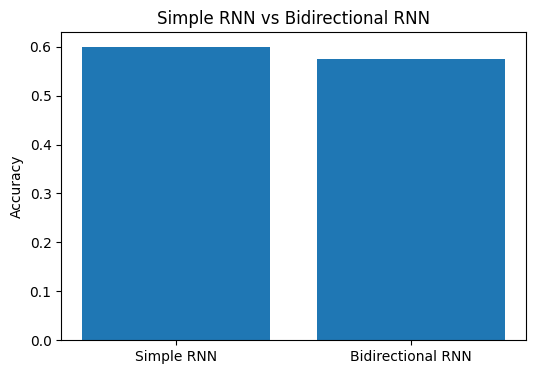

In [11]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Simple RNN vs Bidirectional RNN")
plt.show()